In [ ]:
# Truth seeking (objective questions): is the sign of the net opinion the
# correct answer, and how does that evolve over the 9 rounds?
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import MODELS, load_data, opinions

runs, banks, P, GCLASS = load_data()
T = 9

# Correctness category abbreviations and labels. 
CATS = ["cc", "ii", "ic", "ci", "tie"]
CAT_LABEL = {"cc": "CC", "ii": "II", "ic": "IC", "ci": "CI", "tie": "U"}
CAT_COL = {"cc": "#9a9a9a", "ii": "#9a9a9a", "ic": "#1abc9c",
           "ci": "#cc79a7", "tie": "#9a9a9a"}
CAT_DESC = {"ic": "incorrect → correct", "ci": "correct → incorrect",
            "cc": "correct → correct", "ii": "incorrect → incorrect",
            "tie": "tie at an endpoint"}

# Filter the runs with objective questions.
obj = [r for r in runs if r["mode"] == "objective"]
# Compute the net opinion and ground truth: A(+1) or B(-1) for each run.
for r in obj:
    r["net"] = opinions(r).mean(axis=1)              # net opinion n(t)
    r["gt"] = 1 if r["ground_truth"] == "A" else -1  # A -> +1 pole, B -> -1
print(len(obj), "objective societies")

6400 objective societies


In [ ]:
# per model: % correct per round (ties dropped) and the truth-oriented
# endpoint (gt*n(0), gt*n(8)) with its transition category
accuracy, endpoints, cats = {}, {}, {}

for model, label, short in MODELS:
    # Select the runs corresponding to the current model.
    rows = [r for r in obj if r["model"] == model]
    # Gather the net opinions and ground truths for selected runs.
    net = np.array([r["net"] for r in rows])
    GT = np.array([r["gt"] for r in rows])

    # correct if the sign of the net opinion matches the ground truth, 
    # valid if the net opinion is not zero (to avoid ties).
    correct, valid = np.sign(net) == GT[:, None], net != 0
    # Compute the accuracy as the percentage of correct and valid runs.
    accuracy[short] = 100 * (correct & valid).sum(0) / valid.sum(0)

    # x, y are the ground truth-oriented net opinions at the first and last rounds.
    # x, y are large positive if the net opinion is correct. 
    x, y = GT * net[:, 0], GT * net[:, -1]
    # Categorize the runs based on their initial and final net opinions.
    cat = np.where((net[:, 0] == 0) | (net[:, -1] == 0), "tie", # tie(U) if one of the endpoints is zero
          np.where(x > 0, np.where(y > 0, "cc", "ci"),
                   np.where(y > 0, "ic", "ii")))
    endpoints[short] = (x, y, cat)
    cats[short] = {c: int((cat == c).sum()) for c in CATS}
    print(f"{label:13s} accuracy t=0 {accuracy[short][0]:.1f}% -> "
          f"t=8 {accuracy[short][-1]:.1f}%, IC {cats[short]['ic']}, "
          f"CI {cats[short]['ci']}")

GPT-4o-mini   accuracy t=0 46.5% -> t=8 64.1%, IC 448, CI 176
Gemma-3n-E4B  accuracy t=0 54.9% -> t=8 64.4%, IC 169, CI 18
Qwen3.5-9B    accuracy t=0 63.8% -> t=8 84.4%, IC 436, CI 112
Llama-3-8B    accuracy t=0 38.9% -> t=8 49.7%, IC 254, CI 85


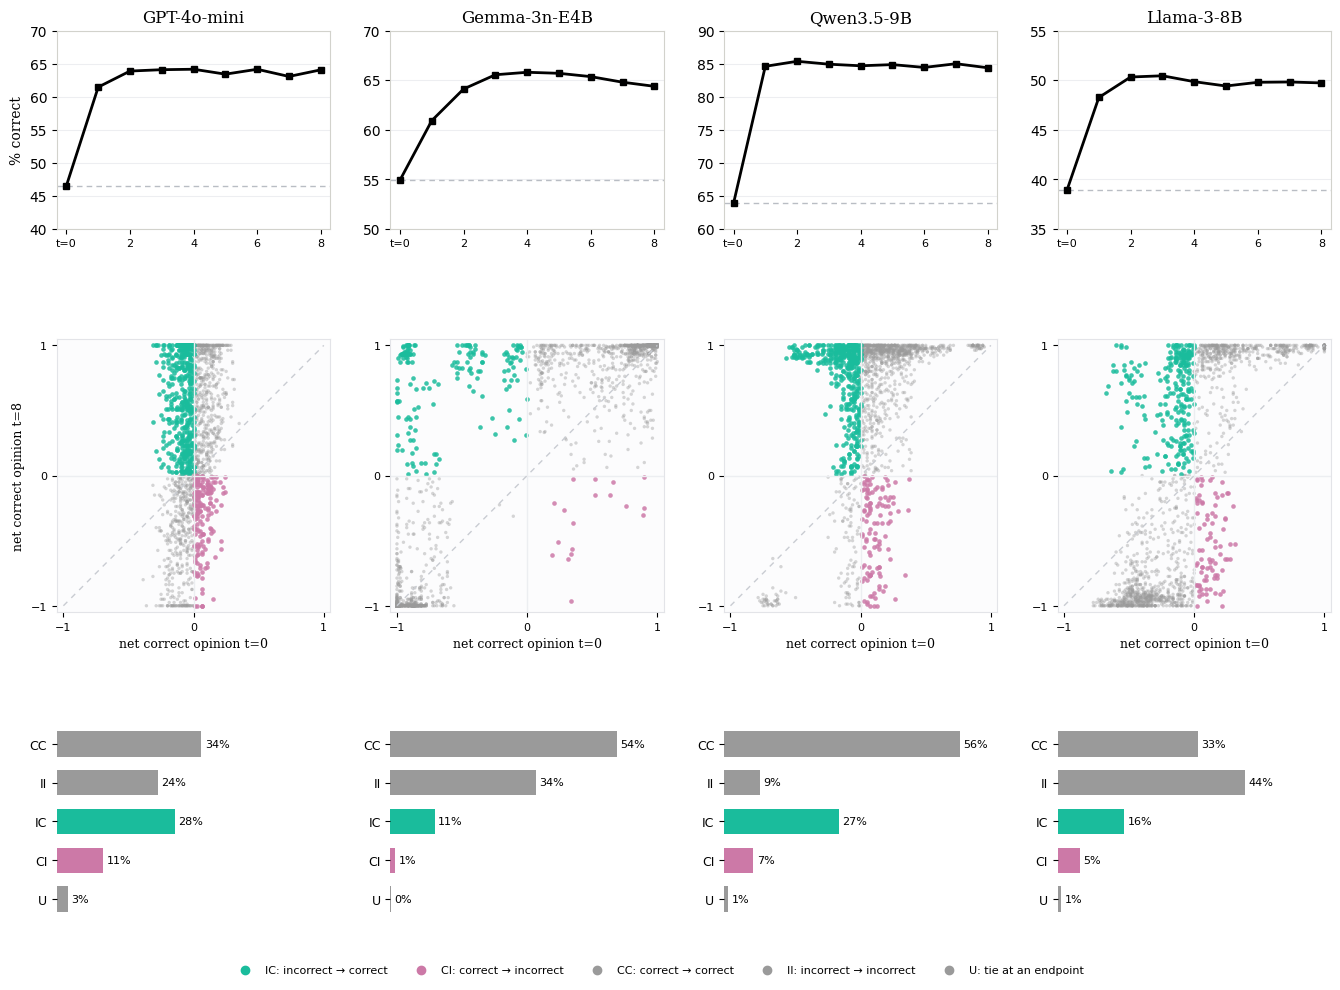

In [ ]:
"""
Figure 5: Truth-seeking tendency
"""
# per model: accuracy line, endpoint scatter (IC/CI highlighted), bars
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(3, 4, height_ratios=[1.0, 1.7, 1.0], hspace=0.32,
                      wspace=0.22, left=0.07, right=0.98, top=0.94, bottom=0.05)
# Compute the maximum percentage of runs in any category across all models for bar chart scaling.
max_bar = max(100 * c / sum(cs.values()) for cs in cats.values()
              for c in cs.values())
# Plotting for each model: accuracy over time, endpoint scatter, and category distribution bar chart.
for j, (model, label, short) in enumerate(MODELS):
    # 1. Accuracy line plot over time
    acc = accuracy[short]
    ax = fig.add_subplot(gs[0, j])
    ax.grid(axis="y", color="#edeef1", lw=0.8)
    ax.axhline(acc[0], color="#b9bdc4", ls=(0, (4, 3)), lw=1)  # round-0 level
    ax.plot(range(T), acc, color="black", lw=2, marker="s", ms=4)
    lo = 5 * np.floor((acc.min() - 2) / 5)
    hi = 5 * np.ceil((acc.max() + 2) / 5)
    ax.set_ylim(lo, max(hi, lo + 10)), ax.set_xlim(-0.3, T - 0.7)
    ax.set_xticks(range(0, T, 2), ["t=0", "2", "4", "6", "8"], fontsize=8)
    ax.set_title(label, fontsize=12, family="serif")
    if j == 0:
        ax.set_ylabel("% correct", fontsize=10, family="serif")
    for s in ax.spines.values():
        s.set_color("#d2d2cc")

    # 2. Endpoint scatter plot of net opinions at t=0 and t=8
    ax = fig.add_subplot(gs[1, j])
    x, y, cat = endpoints[short]
    ax.set_facecolor("#fcfcfd")
    ax.axvline(0, color="#eceef1", lw=1), ax.axhline(0, color="#eceef1", lw=1)
    # Dashed diagonal line representing equal initial and final net opinions.
    ax.plot([-1, 1], [-1, 1], color="#c9ccd2", ls=(0, (4, 4)), lw=1)
    # Points that are CC, II, or tie (U) are in grey color.
    bg = ~np.isin(cat, ["ic", "ci"]) 
    ax.scatter(x[bg], y[bg], s=6, c=[CAT_COL[c] for c in cat[bg]],
               alpha=0.4, lw=0)
    # Points that are IC or CI are highlighted in distinct colors.
    for c in ["ic", "ci"]:
        sel = cat == c
        ax.scatter(x[sel], y[sel], s=11, c=CAT_COL[c], alpha=0.85, lw=0)
    ax.set_xlim(-1.05, 1.05), ax.set_ylim(-1.05, 1.05)
    ax.set_xticks([-1, 0, 1]), ax.set_yticks([-1, 0, 1])
    ax.tick_params(labelsize=8)
    ax.set_xlabel("net correct opinion t=0", fontsize=9, family="serif")
    if j == 0:
        ax.set_ylabel("net correct opinion t=8", fontsize=9, family="serif")
    ax.set_aspect("equal")
    for s in ax.spines.values():
        s.set_color("#e3e4e8")

    # 3. Horizontal bar chart of the percentage of runs in each category
    ax = fig.add_subplot(gs[2, j])
    tot = sum(cats[short].values())
    pct = [100 * cats[short][c] / tot for c in CATS]
    ax.barh(range(len(CATS))[::-1], pct, color=[CAT_COL[c] for c in CATS],
            height=0.65)
    for i, p in enumerate(pct):
        ax.text(p + 0.8, len(CATS) - 1 - i, f"{p:.0f}%", va="center", fontsize=8)
    ax.set_yticks(range(len(CATS))[::-1], [CAT_LABEL[c] for c in CATS], fontsize=9)
    ax.set_xlim(0, 5 * np.ceil((max_bar + 4) / 5))
    ax.set_xticks([])
    for s in ax.spines.values():
        s.set_visible(False)
fig.legend(handles=[plt.Line2D([], [], marker="o", ls="", color=CAT_COL[c],
                               label=f"{CAT_LABEL[c]}: {CAT_DESC[c]}")
                    for c in ["ic", "ci", "cc", "ii", "tie"]],
           loc="lower center", ncol=5, fontsize=8, frameon=False,
           bbox_to_anchor=(0.5, -0.015))
plt.show()

In [ ]:
"""
Accuracy by graph degree
"""
# truth seeking vs connectivity: agent-level accuracy by exact degree in
# the social graph, random signed graphs only (lattices excluded)
DEG_BINS = [str(k) for k in range(8)] + ["8p"]
BIN_LABEL = {**{str(k): str(k) for k in range(8)}, "0": "0 (isolated)", "8p": "8+"}
deg_acc = {}
for model, label, short in MODELS:
    rows = [r for r in obj if r["model"] == model
            and not (np.asarray(r["J"]) >= 0).all()]
    # Tracks the number of correct agents per degree bin over time.
    correct = {b: np.zeros(T) for b in DEG_BINS} 
    count = {b: 0 for b in DEG_BINS}
    for r in rows:
        # Compute the degree
        deg = (np.asarray(r["J"]) != 0).sum(axis=1)
        # Agent correctness: True if the sign of the net opinion matches the ground truth.
        acorr = np.sign(opinions(r)) == r["gt"]      # (9, 32) agent correctness

        # Aggregate correctness and count for each degree bin.
        for b in DEG_BINS:
            mask = (deg >= 8) if b == "8p" else (deg == int(b))
            if mask.any():
                correct[b] += acorr[:, mask].sum(axis=1)
                count[b] += mask.sum()

    # Compute the accuracy percentage for each degree bin.
    deg_acc[short] = {b: 100 * correct[b] / count[b] if count[b] else None
                      for b in DEG_BINS}
print("agents per degree bin:", {b: int(count[b]) for b in DEG_BINS})

agents per degree bin: {'0': 1120, '1': 3280, '2': 8400, '3': 7920, '4': 10320, '5': 4080, '6': 3600, '7': 1840, '8p': 400}


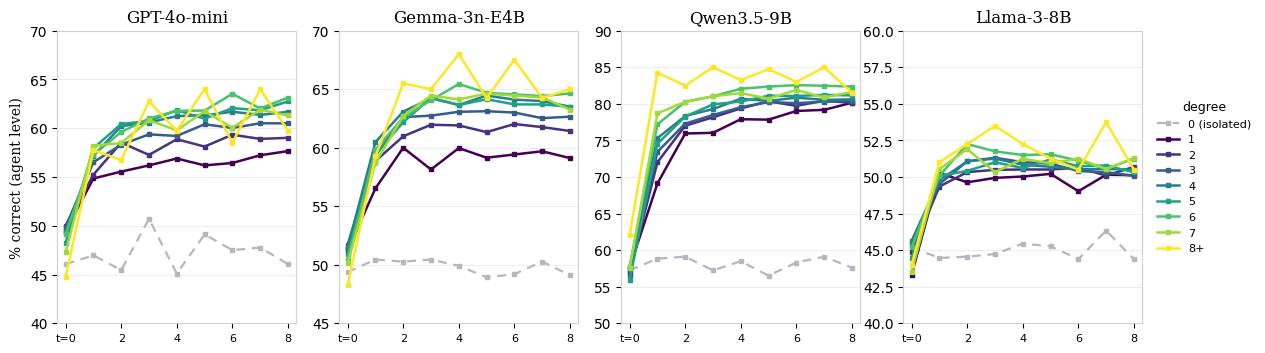

In [5]:
conn_cols = [plt.get_cmap("viridis")(i / 7) for i in range(8)]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.8), gridspec_kw=dict(wspace=0.18))
for j, (model, label, short) in enumerate(MODELS):
    ax = axes[j]
    ax.grid(axis="y", color="#edeef1", lw=0.8)
    vals = np.concatenate([a for a in deg_acc[short].values() if a is not None])
    ci = 0
    for b in DEG_BINS:
        acc = deg_acc[short][b]
        if acc is None:
            continue
        if b == "0":                                 # show agents with no neighbors separately
            ax.plot(range(T), acc, color="#b4b7bd", lw=1.6, ls=(0, (4, 3)),
                    marker="s", ms=2.6, label=BIN_LABEL[b])
        else:
            ax.plot(range(T), acc, color=conn_cols[ci], lw=1.8, marker="s",
                    ms=2.6, label=BIN_LABEL[b])
            ci += 1
    lo = 5 * np.floor((vals.min() - 2) / 5)
    hi = 5 * np.ceil((vals.max() + 2) / 5)
    ax.set_ylim(lo, max(hi, lo + 10)), ax.set_xlim(-0.3, T - 0.7)
    ax.set_xticks(range(0, T, 2), ["t=0", "2", "4", "6", "8"], fontsize=8)
    ax.set_title(label, fontsize=12, family="serif")
    if j == 0:
        ax.set_ylabel("% correct (agent level)", fontsize=10, family="serif")
    for s in ax.spines.values():
        s.set_color("#d2d2cc")
axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8,
                frameon=False, title="degree", title_fontsize=9)
plt.show()